<a href="https://colab.research.google.com/github/Binay-panda19/Deep-Learning/blob/Neural_Networks/01-Neural-Networks/MNIST_Digit_Classification_using_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing the Dependecies

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix

#Loading the MNIST data from keras.datasets

In [6]:
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

In [7]:
type(X_train)

numpy.ndarray

In [8]:
# shape of numpy arrays

print("X_train shape:", X_train.shape)
print("y_train shape:", Y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", Y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


Training data -> 60,000 images

Testing data -> 10,000 images

Dimension of Images --> 28 X 28

GrayScale Images --> 1 color channel

In [10]:
print(X_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

In [11]:
X_train[10].shape

(28, 28)

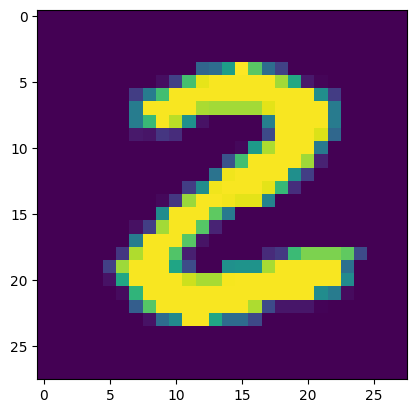


 label :  2


In [16]:
# displaying the single image

img = plt.imshow(X_train[25])
plt.show()

# print the corresponding label
print("\n label : ",Y_train[25])

#Image Labels

In [18]:
print(Y_train.shape, Y_test.shape)

(60000,) (10000,)


In [21]:
# unique labels in Y_train
print(np.unique(Y_train))

# unique labels in Y_test
print(np.unique(Y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


All the images have the same dimensions otherwise, we would have to change the images to a common dimension

In [22]:
# scaling the values
X_train = X_train/255
X_test = X_test/255

#Building the Neural Network

In [26]:
# setting the layers of the Neural Network

model = keras.Sequential([
    keras.layers.Input(shape=(28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(10,activation='sigmoid')
])

In [27]:
# compiling the model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**Training the Model**

In [28]:
# training the model
model.fit(X_train,Y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9160 - loss: 0.2908
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9589 - loss: 0.1383
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9690 - loss: 0.1039
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9747 - loss: 0.0835
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9790 - loss: 0.0697
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9827 - loss: 0.0585
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9851 - loss: 0.0501
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9867 - loss: 0.0432
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9887 - loss: 0.0374
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9898 - loss: 0.0322


Training Data Accuracy --> 98.98 %

**Accuracy on Test Data**

In [31]:
loss, accuracy = model.evaluate(X_test,Y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9696 - loss: 0.1167
Test Loss: 0.11668787896633148
Test Accuracy: 0.9696000218391418


Testing Data Accuracy --> 96.96 %

In [32]:
print(X_test.shape)

(10000, 28, 28)


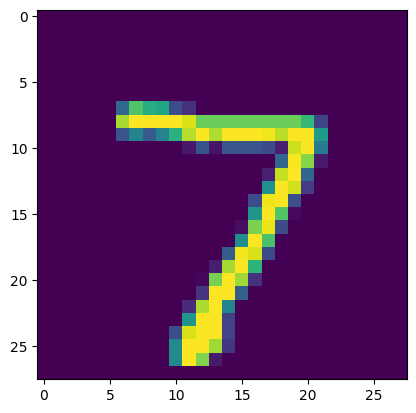


 label :  7


In [33]:
# first data point in the test data
plt.imshow(X_test[0])
plt.show()

print("\n label : ",Y_test[0])

In [34]:
Y_pred = model.predict(X_test)
print(Y_pred.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(10000, 10)


In [35]:
print(Y_pred[0])

[4.16240198e-07 5.52274734e-02 1.17229773e-02 9.90495622e-01
 1.11650756e-04 9.44479346e-01 1.23424133e-12 9.99997497e-01
 2.33196259e-01 9.95041907e-01]


model.predict() gives the probabilty for each class for that data point

In [36]:
# converting the prediction probabilities to class label

label_for_first_test_image = np.argmax(Y_pred[0])
print(label_for_first_test_image)

7


In [38]:
# converting the prediction probabilities to class labels for all the test data points
Y_pred_labels = [np.argmax(i) for i in Y_pred]
print(Y_pred_labels)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(4), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(3), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

Y_test --> true labels

Y_pred_labels --> predicted labels

#Confusion Matrix

In [39]:
conf_matrix = confusion_matrix(Y_test,Y_pred_labels)
print(conf_matrix)

tf.Tensor(
[[ 966    0    3    2    2    1    1    0    1    4]
 [   0 1112    1    6    0    0    5    4    7    0]
 [   6    1  992   12    2    1    3    5   10    0]
 [   1    0    2  990    0    6    0    5    5    1]
 [   0    0    3    0  960    1    5    2    2    9]
 [   2    0    1   20    2  851    6    0    6    4]
 [   3    2    2    2    8    3  935    0    2    1]
 [   2    1   11    8    3    0    0  978    3   22]
 [   1    0    3   11    5    4    4    1  939    6]
 [   0    2    0    3   20    3    0    2    6  973]], shape=(10, 10), dtype=int32)


Text(0.5, 47.7222222222222, 'Predicted Labels')

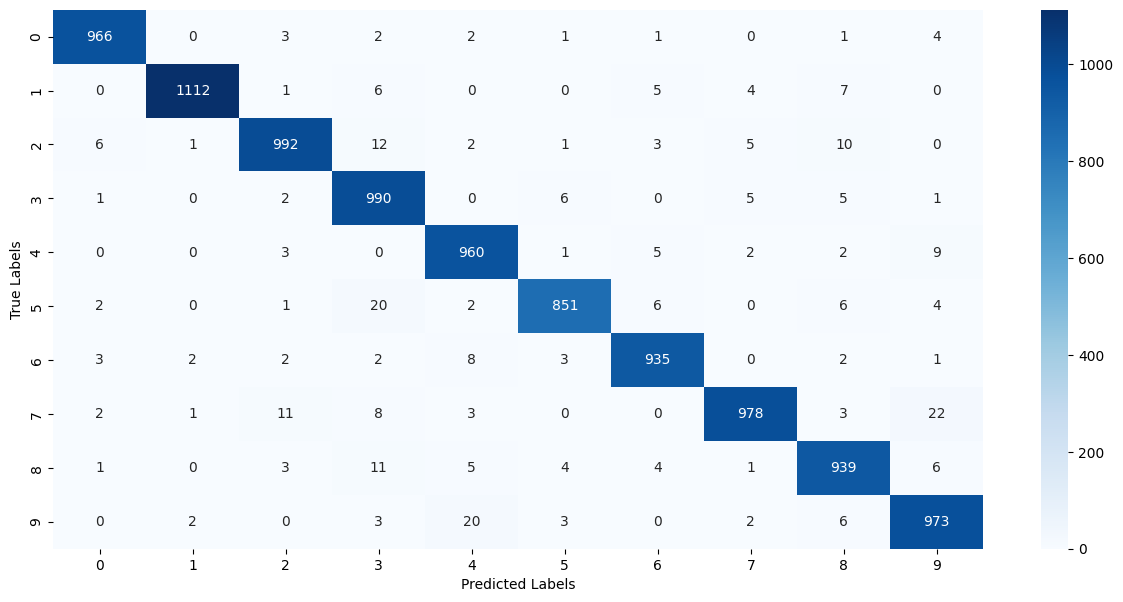

In [40]:
plt.figure(figsize = (15,7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')

#Building a Predictive System

In [42]:
input_image_path = '/content/download.png'

input_image = cv2.imread(input_image_path)

In [43]:
type(input_image)

numpy.ndarray

In [44]:
print(input_image)

[[[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 ...

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]]


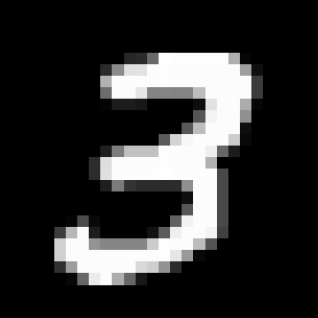

In [45]:
cv2_imshow(input_image)

In [46]:
input_image.shape

(318, 318, 3)

In [47]:
grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

In [48]:
grayscale.shape

(318, 318)

In [49]:
input_image_resize = cv2.resize(grayscale, (28, 28))

In [50]:
input_image_resize.shape

(28, 28)

In [51]:
cv2_imshow(input_image_resize)

In [52]:
input_image_resize = input_image_resize/255

In [53]:
type(input_image_resize)

numpy.ndarray

In [54]:
image_reshaped = np.reshape(input_image_resize, [1,28,28])

In [55]:
input_prediction = model.predict(image_reshaped)
print(input_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
[[1.8307478e-12 1.9787624e-03 2.1377249e-02 1.0000000e+00 1.4998895e-12
  9.9759364e-01 6.8480609e-22 1.0792738e-01 9.5371425e-01 9.8295200e-01]]


In [56]:
input_pred_label = np.argmax(input_prediction)

In [57]:
print(input_pred_label)

3


#**Predictive System**

Path of the image to be predicted: /content/download.png


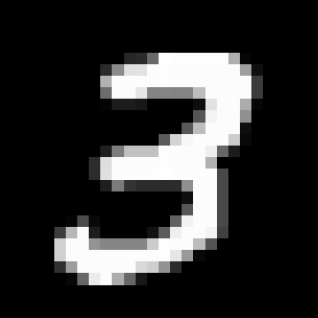

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
 
 The Handwritten Digit is recognised as  3


In [60]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

input_image_resize = cv2.resize(grayscale, (28, 28))

input_image_resize = input_image_resize/255

image_reshaped = np.reshape(input_image_resize, [1,28,28])

input_prediction = model.predict(image_reshaped)

input_pred_label = np.argmax(input_prediction)

print(' \n The Handwritten Digit is recognised as ', input_pred_label)